In [1]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import os

# ----- Preproccessing of training data -----

IS_ZERO_PAD = False
IS_MED_PAD = True

data = pd.read_csv("training.csv")
new_data = {}
norm_factors = {}
median_dict = {}

keys = []
for key in data:
    keys.append(key)
    median_dict[f"_{key}"] = []

for idx, row in tqdm(data.iterrows(), total=len(data)):
    for key in keys:
        if row[key] != -999.0:
            median_dict[f"_{key}"].append(row[key])

for key in keys:
    if key != "Label" and key != "EventId":
        median_dict[key] = np.float32(np.median(median_dict[f"_{key}"]))

for key in data:
    if key == "Label":
        label_nd = data[key].to_numpy()
        label_one_zero = np.where(label_nd == "s", 1, 0).astype(np.float32)
        new_data["Label"] = label_one_zero
    elif key == "Weight":
        new_data["Weight"] = data[key]
    elif key != "EventId":
        data_nd = (
            data[key]
            .replace(
                -999.0, 0 if IS_ZERO_PAD else median_dict[key] if IS_MED_PAD else np.nan
            )
            .to_numpy(dtype=np.float32)
        )
        norm_factors[key] = [data_nd.mean(), data_nd.std(), median_dict[key]]
        new_data[key] = (data_nd - norm_factors[key][0]) / norm_factors[key][1]

new_df = pd.DataFrame(new_data)
split_idx = int(len(new_df) * 0.8)
training_df = new_df.iloc[:split_idx].reset_index(drop=True)
val_df = new_df.iloc[split_idx:].reset_index(drop=True)
os.makedirs("./data", exist_ok=True)
training_df.to_pickle(
    f"./data/training{'_zero_pad' if IS_ZERO_PAD else '_med_pad' if IS_MED_PAD else ''}_std.pt"
)
val_df.to_pickle(
    f"./data/val{'_zero_pad' if IS_ZERO_PAD else '_med_pad' if IS_MED_PAD else ''}_std.pt"
)

norm_df = pd.DataFrame([norm_factors])
norm_df.to_pickle("./data/norm_std.pt")


  0%|          | 0/250000 [00:00<?, ?it/s]

In [2]:
import torch
import torch.nn.functional as F
from torch import nn, optim
from torch.utils.data import DataLoader
from typing import Any
from torchinfo import summary
from fastprogress import master_bar, progress_bar

# ----- Model definition -----

class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, path: str) -> None:
        super().__init__()
        self.df = pd.read_pickle(path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index: int) -> Any:
        data = {"data": [], "Weight": 0.0, "Label": 0.0}
        for key in self.df:
            if str(key) == "Weight":
                data["Weight"] = self.df.at[index, str(key)]
            elif str(key) == "Label":
                data["Label"] = self.df.at[index, str(key)]
            else:
                data["data"].append(self.df.at[index, str(key)])
        data["data"] = torch.tensor(data["data"], dtype=torch.float32)

        return data


class ResNet(nn.Module):
    def __init__(
        self, input_dim: int, hidden_dim: int, dropout_rate: float = 0.15
    ) -> None:
        super().__init__()
        self.norm1 = nn.LayerNorm(input_dim)
        self.first_layer = nn.Linear(input_dim, hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.second_layer = nn.Linear(hidden_dim, input_dim)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x: torch.Tensor):
        h = self.first_layer(self.norm1(x))
        h = F.gelu(h)
        h = self.second_layer(self.norm2(h))
        h = self.dropout(h)
        return x + h


class CustomMLP(nn.Module):
    def __init__(
        self,
        in_dim: int,
        embed_dim: int,
        hidden_dim_list1: list[int],
        hidden_dim_list2: list[int],
        dropout: float = 0.25,
        input_dropout: float = 0.1,
    ) -> None:
        super().__init__()
        self.input_dropout = nn.Dropout(input_dropout)
        self.embedding = nn.Linear(in_dim, embed_dim)
        self.mlp1 = nn.ModuleList()
        for i in range(len(hidden_dim_list1)):
            self.mlp1.append(ResNet(embed_dim, hidden_dim_list1[i], dropout))
            if i != len(hidden_dim_list1) - 1:
                self.mlp1.append(nn.GELU())
        self.mlp2 = nn.ModuleList()
        for i in range(len(hidden_dim_list2)):
            self.mlp2.append(ResNet(embed_dim, hidden_dim_list2[i], dropout))
            if i != len(hidden_dim_list2) - 1:
                self.mlp2.append(nn.GELU())
        self.conv1 = nn.Linear(embed_dim, 32)
        self.conv2 = nn.Linear(32, 1)
        # self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor):
        x = self.embedding(self.input_dropout(x))
        for layer in self.mlp1:
            x = layer(x)
        x = F.gelu(x)
        res_x = x
        # x = self.dropout(x)
        for layer in self.mlp2:
            x = layer(x)
        if len(self.mlp2) > 0:
            x = F.gelu(x + res_x)
        x = F.gelu(self.conv1(x))
        x = self.conv2(x)
        return F.sigmoid(x.squeeze(-1))


def get_model_and_dataloader(
    device: str = "cpu", batch_size: int = 32
):
    train_dataset = CustomDataset("./data/training_med_pad_std.pt")
    val_dataset = CustomDataset("./data/val_med_pad_std.pt")
    train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size)

    model = CustomMLP(30, 64, [192, 192, 192], [64, 64, 64], 0.1, 0.03)
    # model = CustomMLP(30, 128, [128, 128, 256, 128], [32, 64], 0.1, 0.03)
    model.to(device=device)
    summary(model)
    return model, train_loader, val_loader


def train_and_val(
    model: CustomMLP,
    train_loader: Any,
    val_loader: Any,
    num_epochs: int = 1,
    lr: float = 1e-3,
):
    device = "mps"
    criterion = nn.BCELoss()

    no_decay = ["bias", "LayerNorm.weight", "LayerNorm.bias"]
    params_to_optimize = [
        {
            "params": [
                p
                for n, p in model.named_parameters()
                if not any(nd in n for nd in no_decay)
            ],
            "weight_decay": 0.06,
        },
        {
            "params": [
                p
                for n, p in model.named_parameters()
                if any(nd in n for nd in no_decay)
            ],
            "weight_decay": 0.0,
        },
    ]
    optimizer = optim.AdamW(params_to_optimize, lr=lr)

    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer,
        lambda epoch: 0.2 ** (3 - epoch) if epoch <= 3 else 0.95 ** (epoch - 3),
    )

    signal: list[float] = []
    background: list[float] = []
    weights = {"signal": [], "background": []}

    mb = master_bar(range(num_epochs))
    x = []
    y_train = []
    y_val = []

    saved_epoch = 0

    for epoch in mb:
        train_loss = torch.tensor(0)
        val_loss = torch.tensor(0)
        x.append(epoch)
        y = 0
        mb.main_bar.comment = f"lr = {scheduler.get_lr()[0] if epoch != 0 else 0.0}"
        model.train()
        for data in progress_bar(train_loader, parent=mb):
            outputs = model(data["data"].to(device))
            train_loss = criterion(outputs, data["Label"].to(torch.float32).to(device))
            y += train_loss.item()

            optimizer.zero_grad()
            train_loss.backward()
            optimizer.step()
        y_train.append(y / len(train_loader))

        y = 0
        model.eval()
        with torch.no_grad():
            signal = []
            background = []
            weights = {"signal": [], "background": []}
            for data in progress_bar(val_loader, parent=mb):
                outputs = model(data["data"].to(device)).to("cpu")
                val_loss = criterion(outputs, data["Label"].to(torch.float32).to("cpu"))
                y += val_loss.item()
                for i in range(len(data["Label"])):
                    if data["Label"][i] == 1.0:
                        signal.append(outputs[i].item())
                        weights["signal"].append(data["Weight"][i])
                    else:
                        background.append(outputs[i].item())
                        weights["background"].append(data["Weight"][i])
        y_val.append(y / len(val_loader))
        scheduler.step()

        if min(y_val) == y_val[-1]:
            torch.save(
                model.to("cpu").state_dict(), "./model/mlp_resnet_plus_model.pth"
            )
            model.to(device=device)
            saved_epoch = epoch

        mb.update_graph(
            [[x, y_train], [x, y_val]],
            [0, max(1, epoch)],
            [min(min(y_train), min(y_val)), max(max(y_train), max(y_val))],
        )
        mb.write(
            f"Epoch [{epoch + 1}/{num_epochs}], train Loss: {y_train[-1]:.4f}, val Loss: {y_val[-1]:.4f} {'(saved)' if saved_epoch == epoch else ''}"
        )

        if epoch - saved_epoch >= 7:
            mb.write("early stopping...")
            break

    return signal, background, weights

In [3]:
batch_size = 256
device = "mps" # Apple Silicon: mps, GPU: cuda
model, train_loader, val_loader = get_model_and_dataloader(
    device=device, batch_size=batch_size
)
model.to(device=device)

os.makedirs("./model", exist_ok=True)

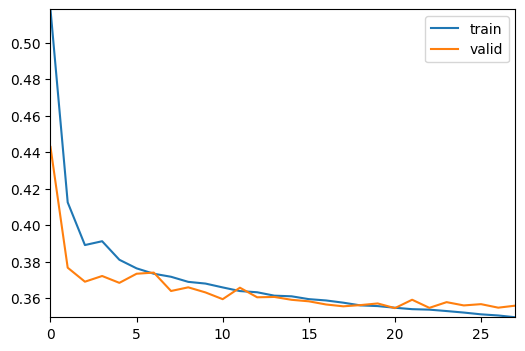

/Users/tom/physics/learning_physics/venv/lib/python3.13/site-packages/torch/optim/lr_scheduler.py:367: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)


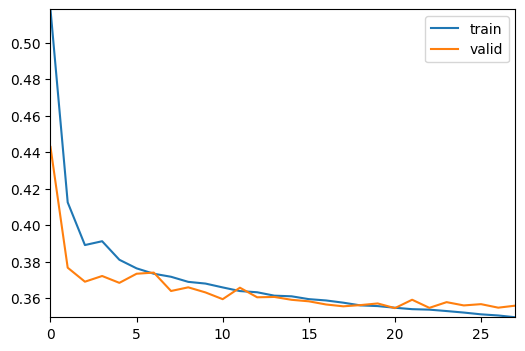

In [4]:
# ----- training -----
signal, background, weights = train_and_val(
    model, train_loader, val_loader, num_epochs=40, lr=0.002
)

  0%|          | 0/196 [00:00<?, ?it/s]

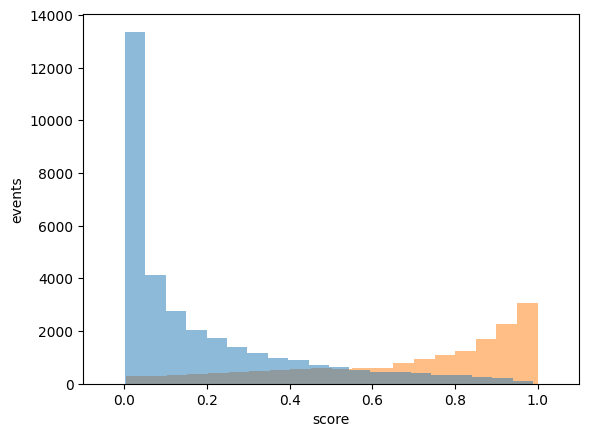

In [5]:
import matplotlib.pyplot as plt

# ----- Evaluation of validation dataset -----
loader = val_loader

params = torch.load("./model/mlp_resnet_plus_model.pth")
model.load_state_dict(params)
model.to(device="cpu")

signal = []
background = []
weights = {"signal": [], "background": []}
for data in tqdm(loader):
    output = model(data["data"])
    for i in range(len(data["Label"])):
        if data["Label"][i] == 1.0:
            signal.append(output[i].item())
            weights["signal"].append(data["Weight"][i])
        else:
            background.append(output[i].item())
            weights["background"].append(data["Weight"][i])

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ax.hist(signal, bins=20, color="tab:orange", alpha=0.5)
ax.hist(background, bins=20, color="tab:blue", alpha=0.5)
ax.set_xlabel("score")
ax.set_ylabel("events")
ax.set_xlim(-0.1, 1.1)
plt.show()

Max AMS: 1.5924911616764927, b_r = 10
Max AMS: 1.5718509452808187, b_r = 30


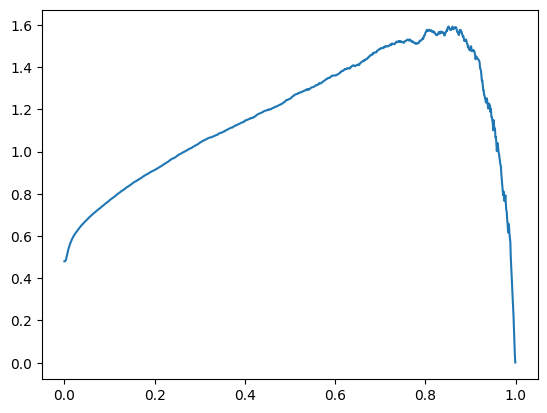

In [6]:
# ----- Calculation of AMS -----
weight_s = np.array(weights["signal"])
weight_b = np.array(weights["background"])

num_split = 1000
x = [1.0 / num_split * i for i in range(num_split)]
s = np.zeros(num_split)
b = np.zeros(num_split)

signal = np.array(signal)
background = np.array(background)

for i in range(num_split):
    s[i] = np.inner((signal >= x[i]), weight_s)
    b[i] = np.inner((background >= x[i]), weight_b)

ams_10 = np.sqrt(2.0 * ((s + b + 10) * np.log(1.0 + s / (b + 10)) - s))
print(f"Max AMS: {ams_10.max()}, b_r = {10}")
ams_30 = np.sqrt(2.0 * ((s + b + 30) * np.log(1.0 + s / (b + 30)) - s))
print(f"Max AMS: {ams_30.max()}, b_r = {30}")

plt.plot(x, ams_10)
plt.show()

  0%|          | 0/2149 [00:00<?, ?it/s]

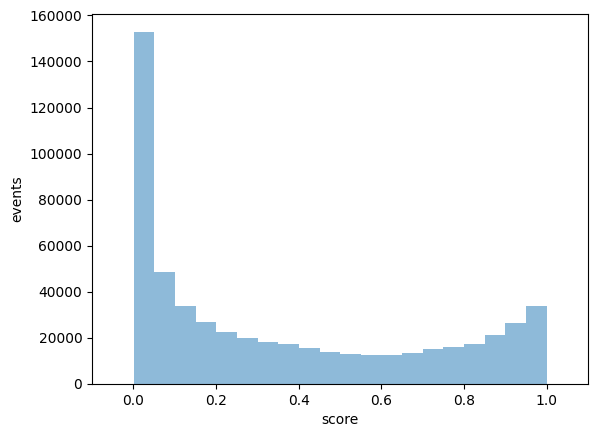

In [7]:
# ----- Evaluation of test dataset -----
data = pd.read_csv("test.csv")
new_data = {}
label_flag = False

norm_dict = pd.read_pickle("./data/norm_std.pt")

for key in data:
    if key == "Label":
        label_nd = data[key].to_numpy()
        label_one_zero = np.where(label_nd == "s", 1, 0).astype(np.float32)
        label_flag = True if len(label_one_zero) > 0 else False
        new_data["Label"] = label_one_zero
    elif key == "Weight":
        new_data["Weight"] = data[key]
    elif key != "EventId":
        norm = norm_dict[key][0]
        data_nd = (
            data[key]
            .replace(
                -999.0, 0 if IS_ZERO_PAD else norm[2] if IS_MED_PAD else np.nan
            )
            .to_numpy(dtype=np.float32)
        )
        new_data[key] = (data_nd - norm[0]) / norm[1]

new_df = pd.DataFrame(new_data)
new_df.to_pickle(
    f"./data/test{'_zero_pad' if IS_ZERO_PAD else '_med_pad' if IS_MED_PAD else ''}_std.pt"
)

test_dataset = CustomDataset(f"./data/test{'_zero_pad' if IS_ZERO_PAD else '_med_pad' if IS_MED_PAD else ''}_std.pt")
loader = DataLoader(test_dataset, batch_size)

params = torch.load("./model/mlp_resnet_plus_model.pth")
model.load_state_dict(params)
model.to(device="cpu")

signal = []
background = []
all_events = []
weights = {"signal": [], "background": []}
for data in tqdm(loader):
    output = model(data["data"])
    if label_flag:
        for i in range(len(data["Label"])):
            if data["Label"][i] == 1.0:
                signal.append(output[i].item())
                weights["signal"].append(data["Weight"][i])
            else:
                background.append(output[i].item())
                weights["background"].append(data["Weight"][i])
    else:
        for i in range(len(data["data"])):
            all_events.append(output[i].item())

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

if label_flag:
    ax.hist(signal, bins=20, color="tab:orange", alpha=0.5)
    ax.hist(background, bins=20, color="tab:blue", alpha=0.5)
else:
    ax.hist(all_events, bins=20, color="tab:blue", alpha=0.5)
ax.set_xlabel("score")
ax.set_ylabel("events")
ax.set_xlim(-0.1, 1.1)
plt.show()

In [8]:
# ----- Calculation of AMS -----
if label_flag:
    weight_s = np.array(weights["signal"])
    weight_b = np.array(weights["background"])

    num_split = 1000
    x = [1.0 / num_split * i for i in range(num_split)]
    s = np.zeros(num_split)
    b = np.zeros(num_split)

    signal = np.array(signal)
    background = np.array(background)

    for i in range(num_split):
        s[i] = np.inner((signal >= x[i]), weight_s)
        b[i] = np.inner((background >= x[i]), weight_b)

    ams_10 = np.sqrt(2.0 * ((s + b + 10) * np.log(1.0 + s / (b + 10)) - s))
    print(f"Max AMS: {ams_10.max()}, b_r = {10}")
    ams_30 = np.sqrt(2.0 * ((s + b + 30) * np.log(1.0 + s / (b + 30)) - s))
    print(f"Max AMS: {ams_30.max()}, b_r = {30}")

    plt.plot(x, ams_10)
    plt.show()
else:
    print("No label infomation. Skip the AMS calculation")

No label infomation. Skip the AMS calculation
